Программа, считающая количество объектов для классов Head (ID = 0) и Helmet (ID = 1).

In [5]:
from google.colab import files
import zipfile
import os
from collections import Counter

# Загрузка лёгкого архива
print("Загрузите ZIP только с папками labels:")
uploaded = files.upload()

# Распаковка (секунды, а не минуты)
for filename in uploaded.keys():
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall('/content/labels_only')
    print("Готово!")

# Подсчёт
path_to_labelss = [
    "/content/labels_only/train/labels",
    "/content/labels_only/valid/labels",
    "/content/labels_only/test/labels"
]

class_counts = Counter()
for path in path_to_labelss:
    if os.path.exists(path):
        for f in os.listdir(path):
            if f.endswith(".txt"):
                with open(os.path.join(path, f)) as file:
                    for line in file:
                        parts = line.strip().split()
                        if parts:
                            class_counts[int(parts[0])] += 1

print("\nСтатистика:")
for cid, cnt in sorted(class_counts.items()):
    print(f"Класс {cid}: {cnt} объектов")

Загрузите ZIP только с папками labels:


Saving dataset_labels.zip to dataset_labels.zip
Готово!

Статистика:
Класс 0: 6677 объектов
Класс 1: 19747 объектов


Программа, выводящая распределение всех объектов по классам.

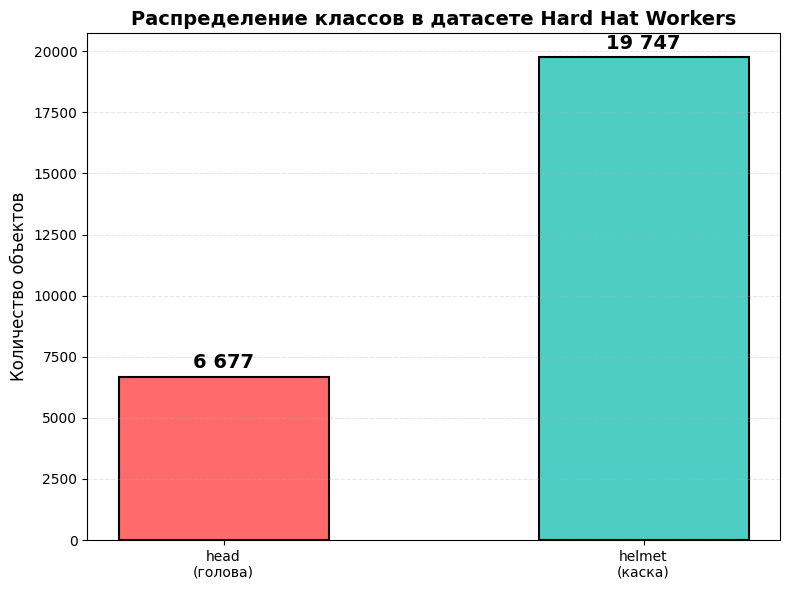

In [4]:
import matplotlib.pyplot as plt

# Данные (уже известны заранее)
labels = ['head\n(голова)', 'helmet\n(каска)']
values = [6677, 19747]
colors = ['#FF6B6B', '#4ECDC4']

# Построение столбчатой диаграммы
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=1.5, width=0.5)

# Подписи значений над столбцами
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(values)*0.01,
            f'{value:,}'.replace(',', ' '),
            ha='center', va='bottom', fontsize=14, fontweight='bold')

# Оформление
ax.set_ylabel('Количество объектов', fontsize=12)
ax.set_title('Распределение классов в датасете Hard Hat Workers', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()